/tmp/ipykernel_221/2253185782.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


                Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0    0.000000e+00       1.532002e-01       8.047656e-01       4.797157e-01   
1    5.000000e-02       1.531611e-01       7.995971e-01       4.796919e-01   
2    1.000000e-01       1.530438e-01       7.843303e-01       4.794846e-01   
3    1.500000e-01       1.528487e-01       7.596591e-01       4.787147e-01   
4    2.000000e-01       1.525761e-01       7.266708e-01       4.768415e-01   
...           ...                ...                ...                ...   
1996 9.980000e+01       3.908078e-09       1.775758e-10       6.917732e-14   
1997 9.985000e+01       3.890587e-09       1.767804e-10       6.881922e-14   
1998 9.990000e+01       3.873158e-09       1.759879e-10       6.846273e-14   
1999 9.995000e+01       3.855790e-09       1.751981e-10       6.810783e-14   
2000 1.000000e+02       3.838481e-09       1.744110e-10       6.775452e-14   

          J_1s(2)      J_2s(2)      J_2p(2)  J_total_carbon  
0

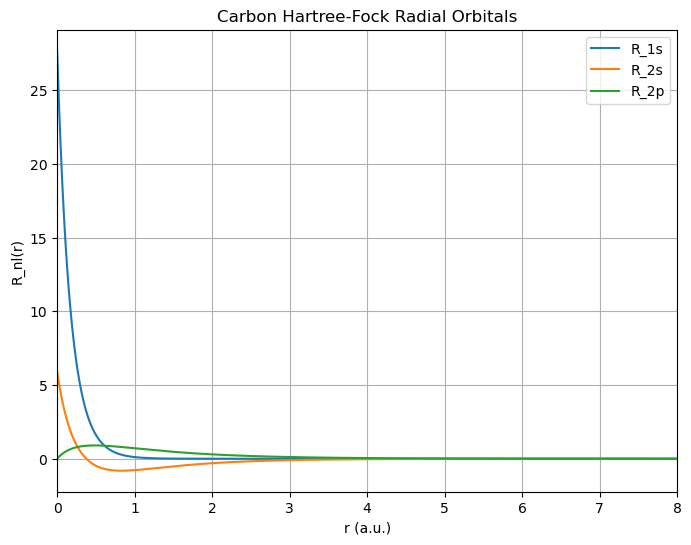

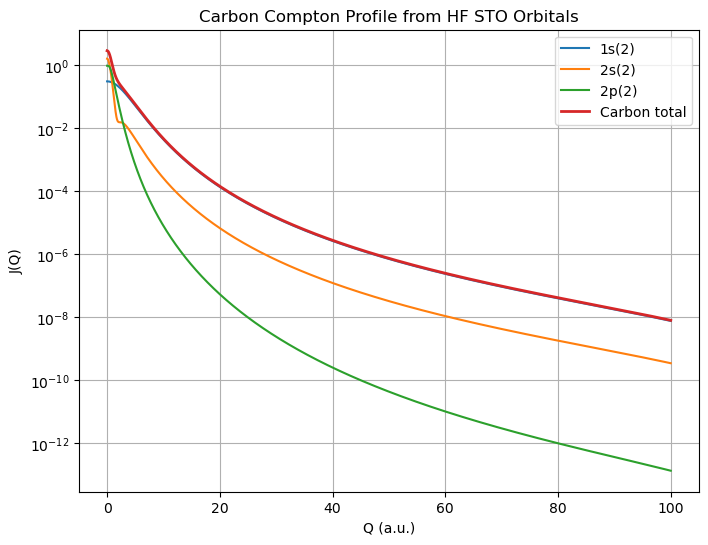

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Carbon Hartree-Fock STO data from your table
# r and p are in atomic units
# =====================================================

# Format: (n_j, Z_j, C_j)
carbon_1s = [
    (1, 8.4936,  0.352872),
    (1, 4.8788,  0.473621),
    (3,15.4660, -0.001199),
    (2, 7.0500,  0.210887),
    (2, 2.2640,  0.000886),
    (2, 1.4747,  0.000465),
    (2, 1.1639, -0.000119),
]

carbon_2s = [
    (1, 8.4936, -0.071727),
    (1, 4.8788,  0.438307),
    (3,15.4660, -0.000383),
    (2, 7.0500, -0.091194),
    (2, 2.2640, -0.393105),
    (2, 1.4747, -0.579121),
    (2, 1.1639, -0.126067),
]

carbon_2p = [
    (2, 7.0500, 0.006977),
    (2, 3.2275, 0.070877),
    (2, 2.1908, 0.230802),
    (2, 1.4413, 0.411931),
    (2, 1.0242, 0.350701),
]

# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build carbon radial orbitals
# =====================================================

R1s = R_nl(r, carbon_1s)
R2s = R_nl(r, carbon_2s)
R2p = R_nl(r, carbon_2p)

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

# Carbon has 1s2 2s2 2p2
J_total = 2*J_1s + 2*J_2s + 2*J_2p

# =====================================================
# Print and save table
# =====================================================

table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(2)": 2*J_2p,
    "J_total_carbon": J_total
})

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.6e}".format)

print(table)

table.to_csv("carbon_HF1_Compton_profile.csv", index=False)
print("\nSaved: carbon_HF1_Compton_profile.csv")

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Carbon Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 2*J_2p, label="2p(2)")
plt.plot(Q, J_total, label="Carbon total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Carbon Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()